# 3.1

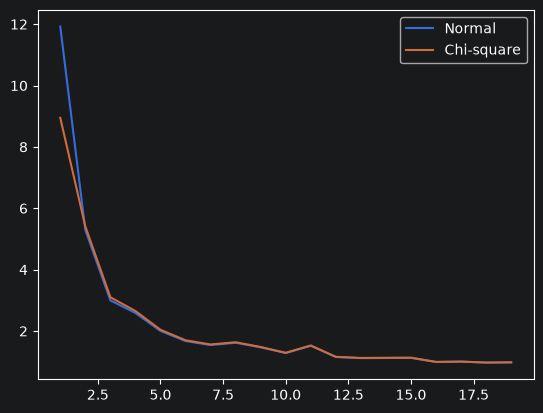

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import pt

ns = range(1,20)
lam = 1
def obs_info(theta, n):
    return n / theta**2

def normal_confint(theta, n, z_alpha = 1.96):

    lower = (theta - z_alpha*obs_info(theta, n)**(-0.5))
    upper = (theta + z_alpha*obs_info(theta, n)**(-0.5))
    return lower, upper

def log_likelihood(theta, x):
    n = len(x)
    return n * np.log(theta) - theta * np.sum(x)

def chi_square_confint(mle, x, cp = 3.84):
    thetas = np.linspace(0.01 * mle,3*mle,1000)
    thetas = [t for t in thetas if log_likelihood(t, x) >= log_likelihood(mle, x) - 0.5 * cp]
    lower, upper = min(thetas), max(thetas)
    return lower, upper

normal_ci_lengths = {}
chi_square_ci_lengths = {}
normal_coverages = {}
chi_square_coverages = {}

for n in ns:

    normal_ci_length = []
    chi_square_ci_length = []
    normal_coverage = []
    chi_square_coverage = []


    for i in range(30):
        x = np.random.exponential(lam, n)

        mle = 1 / np.mean(x)

        l, u = normal_confint(mle, n)
        normal_ci_length.append(u-l)
        normal_coverage.append(l <= lam <= u)


        l, u = chi_square_confint(mle, x)
        chi_square_ci_length.append(u-l)
        chi_square_coverage.append(l <= lam <= u)

    normal_ci_lengths[n] = np.mean(normal_ci_length)
    normal_coverages[n] = np.mean(normal_coverage)
    chi_square_ci_lengths[n] = np.mean(chi_square_ci_length)
    chi_square_coverages[n] = np.mean(chi_square_coverage)

x,y = zip(*normal_ci_lengths.items())
plt.plot(x,y, label = "Normal")
x,y = zip(*chi_square_ci_lengths.items())
plt.plot(x,y, label = "Chi-square")
plt.legend()
plt.show()



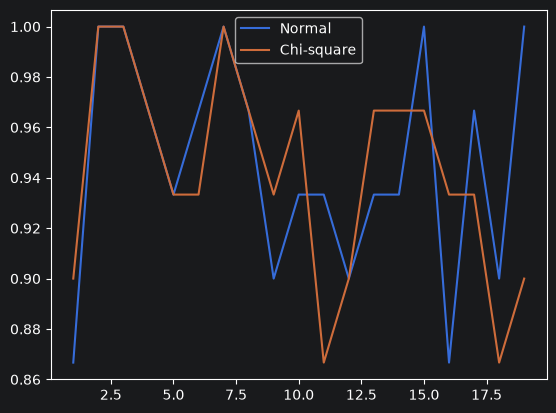

In [16]:
n, coverage = zip(*normal_coverages.items())
plt.plot(n,coverage, label = "Normal")
n, coverage = zip(*chi_square_coverages.items())
plt.plot(n,coverage, label = "Chi-square")
plt.legend()
plt.show()

# 3.2 Simulations

In [56]:
r = 3
lam = 4
n = 1000
m = 30
x = np.random.gamma(r, 1/lam, (n,m))
xbar  = np.mean(x, axis = 1)
print(len(xbar))

# a)
print("a)")
h = lambda x: x
sample_variance = np.var(h(xbar))
print("Sample variance = ", sample_variance)
theoretical_variance = r / (lam**2 * m)
print("Theoretical variance = ", theoretical_variance)
print()

print("b)")
h = lambda x: x**2
sample_variance = np.var(h(xbar))
print("Sample variance = ", sample_variance)
theoretical_variance = 4*r**3 / (lam**4 * m)
print("Theoretical variance = ", theoretical_variance)
print()

print("c)")
h = lambda x: np.log(x)
sample_variance = np.var(h(xbar))
print("Sample variance = ", sample_variance)
theoretical_variance = r / m
print("Theoretical variance = ", theoretical_variance)
print()

print("d)")
h = lambda x: np.sqrt(x)
sample_variance = np.var(h(xbar))
print("Sample variance = ", sample_variance)
theoretical_variance = 1 / (4*m*lam)
print("Theoretical variance = ", theoretical_variance)





1000
a)
Sample variance =  0.0058751908068141335
Theoretical variance =  0.00625

b)
Sample variance =  0.013626087546963966
Theoretical variance =  0.0140625

c)
Sample variance =  0.010496862206359935
Theoretical variance =  0.1

d)
Sample variance =  0.0019547732379486217
Theoretical variance =  0.0020833333333333333
